> # 📉 Customer Churn Prediction

## 🎯 Goal
Predict whether a customer is likely to churn using historical customer data.



## 💼 Business Objectives
- 📉 Reduce customer churn  
- ⚠️ Identify high-risk customers  
- 🎯 Enable targeted retention strategies

---

## 📚 Import Basic Libraries

In [1]:
# Let us import the basic required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


---

## 📥 Load Dataset

In [53]:
df=pd.read_excel("../dataset/Telco_customer_churn.xlsx")

---

## 🔍 Data Undetstanding

In [3]:
pd.set_option('display.max_columns',None)


In [4]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.shape

(7043, 33)

In [6]:
df['Count'].value_counts()

# count Only have 1 value 

Count
1    7043
Name: count, dtype: int64

In [7]:
df['Country'].value_counts()

# Country Only have 1 value 


Country
United States    7043
Name: count, dtype: int64

In [8]:
for col in df.columns:
    if df[col].nunique() < 2:
        print(df[col].value_counts())

Count
1    7043
Name: count, dtype: int64
Country
United States    7043
Name: count, dtype: int64
State
California    7043
Name: count, dtype: int64


In [9]:
df['Zip Code'].nunique()

1652

---
> ### Observation-1
#### We do not need this cols
- CustomerId : As this one is not used in modeling and in analysis either 
- single valued cols: [ Count, Country , State ]
- Lat Long: we already have separete latitude and longitude cols
---

In [10]:
pd.set_option('display.max_rows',None)
df.groupby('City')['Zip Code'].nunique()

City
Acampo                     1
Acton                      1
Adelanto                   1
Adin                       1
Agoura Hills               1
Aguanga                    1
Ahwahnee                   1
Alameda                    2
Alamo                      1
Albany                     1
Albion                     1
Alderpoint                 1
Alhambra                   2
Aliso Viejo                1
Alleghany                  1
Alpaugh                    1
Alpine                     1
Alta                       1
Altadena                   1
Alturas                    1
Alviso                     1
Amador City                1
Amboy                      1
Anaheim                    7
Anderson                   1
Angels Camp                1
Angelus Oaks               1
Angwin                     1
Annapolis                  1
Antelope                   1
Antioch                    1
Anza                       1
Apple Valley               2
Applegate                  1
Aptos    

---
> ### Observation-2
- Most cities have only 1 zip code.
A few large cities have many.

| City          | Zip Codes |
| ------------- | --------- |
| Los Angeles   | 61        |
| San Diego     | 30        |
| San Jose      | 28        |
| San Francisco | 26        |
| Sacramento    | 27        |
| Fresno        | 16        |
| Long Beach    | 12        |
| Stockton      | 11        |
| Bakersfield   | 10        |
| Oakland       | 13        |

---
But ~90% of cities = 1 zip code.

---

 What this means for our dataset

- City and Zip Code are almost one-to-one.

 That means:

- City ≈ Zip Code

Keeping both adds redundant information.

In [11]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [12]:
df['Payment Method'].value_counts()

Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

<Axes: xlabel='Contract'>

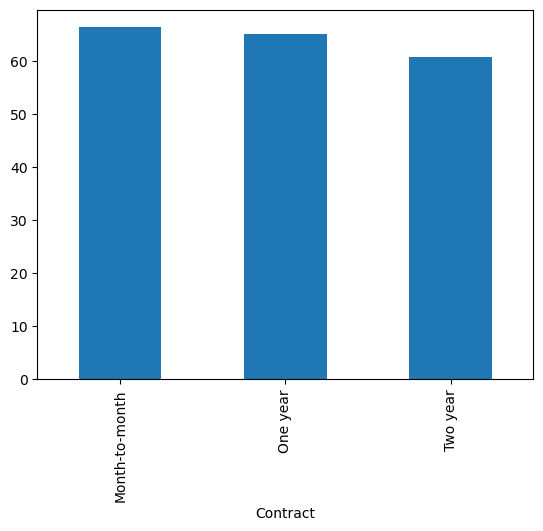

In [13]:
df.groupby('Contract')['Monthly Charges'].mean().plot(kind='bar')

In [14]:
for col in ['Churn Label','Churn Value']:
    print(df[col].value_counts())

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64
Churn Value
0    5174
1    1869
Name: count, dtype: int64


---
> ### Observation-3
- Churn Label and Churn Value Represent same thing 
 
 |Churn Label = 'Yes' | churn Label = 'No' |
 | -------------------|--------------      |
 |Churn Value = 1     | Churn Value = 1    |

- Keeping both adds redundant information.
---

In [15]:
df['Churn Reason'].value_counts()

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Limited range of services                     44
Long distance charges                         44
Lack of affordable download/upload speed      44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

> ### Observation-3

- **Churn Reason** is post-event information. It exists only after the customer has already churned. Using it in a churn prediction model causes data leakage.

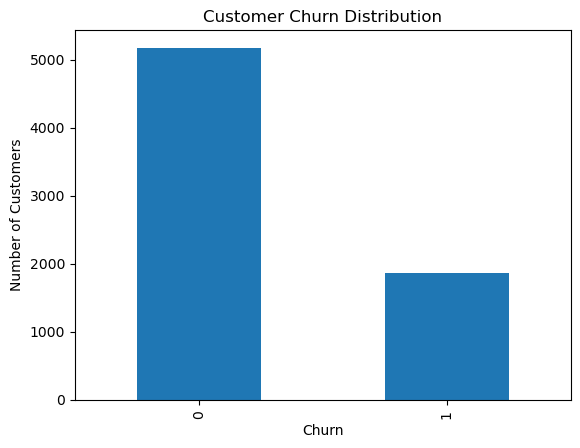

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [16]:

df['Churn Value'].value_counts().plot(kind='bar')

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")

plt.show()

df['Churn Value'].value_counts()

In [17]:
churn_dist = df['Churn Value'].value_counts().to_frame(name='Count')
churn_dist['Percentage'] = (df['Churn Value'].value_counts(normalize=True)*100).round(2)
churn_dist

,Count,Percentage
Churn Value,,
0,5174,73.46
1,1869,26.54


> ## observation -4 
- The dataset shows a **moderate class imbalance** with approximately **73% non-churn** customers and **27% churn** customers.

In [18]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

> ## observation -5 
- The dataset contains No Null Values.

---


## 🧹 Data Cleaning

In [25]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [19]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [24]:
df.duplicated().any()

False

In [26]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

---
### Dropping Irrelevant and Leakage Columns

The following columns are removed from the dataset because they do not contribute to predictive modeling or may introduce data leakage.

#### 1. Irrelevant / Identifier Columns
These columns do not provide meaningful information for churn prediction.

- **Count** – Constant value for all rows.
- **Country** – Same value across the dataset.
- **State** – Same value across the dataset.
- **CustomerID** – Unique identifier, no predictive value.
- **Lat Long** – Geographic coordinates not useful for churn modeling.

#### 2. Target Leakage Columns
These columns contain information that is directly or indirectly related to the target variable and can cause **data leakage**, leading to unrealistic model performance.

- **Churn Label** – Duplicate representation of the target variable.
- **Churn Reason** – Available only after a customer has churned.
- **Churn Score** – Generated by an existing churn prediction model.
- **CLTV (Customer Lifetime Value)** – Often calculated using churn-related assumptions.

Removing these columns ensures the model learns patterns from **genuine customer behavior features** rather than leaked or redundant information.

---

In [54]:
# Columns to remove
drop_cols = [
    'Count',
    'Country',
    'State',
    'CustomerID',
    'Lat Long',
    'Churn Label',
    'Churn Reason',
    'Churn Score',
    'CLTV',
    'Latitude',
      'Longitude'
]

# Drop columns
df.drop(columns=drop_cols, inplace=True)

# Verify
df.columns

Index(['City', 'Zip Code', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='object')

In [55]:
df.shape

(7043, 22)

In [56]:
df.head()

,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


In [57]:
df.describe()

,Zip Code,Tenure Months,Monthly Charges,Churn Value
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,93521.964646,32.371149,64.761692,0.265370
std,1865.794555,24.559481,30.090047,0.441561
min,90001.000000,0.000000,18.250000,0.000000
25%,92102.000000,9.000000,35.500000,0.000000
50%,93552.000000,29.000000,70.350000,0.000000
75%,95351.000000,55.000000,89.850000,1.000000
max,96161.000000,72.000000,118.750000,1.000000


In [59]:
df.dtypes.value_counts()

object     18
int64       3
float64     1
Name: count, dtype: int64

In [65]:
categorical_cols = list(df.select_dtypes(include='object').columns)
categorical_cols

['City',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Total Charges']

---


## 📊 Exploratory Data Analysis

In [66]:
df['Churn Value'].value_counts(normalize=True)

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

<Axes: xlabel='Churn Value', ylabel='count'>

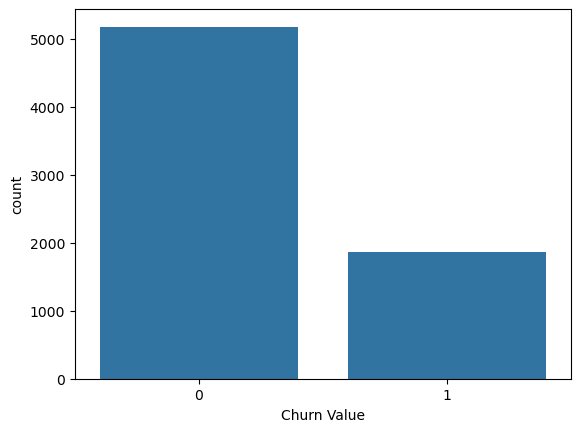

In [67]:
import seaborn as sns
sns.countplot(data=df,x='Churn Value')

> ### Observation -1
~26% customers churned
Dataset is imbalanced

<Axes: xlabel='Tenure Months', ylabel='Count'>

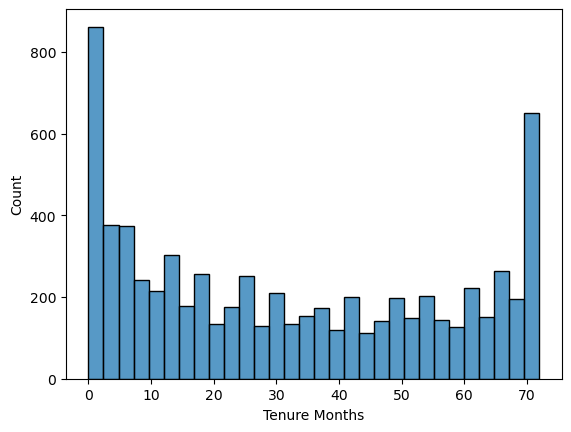

In [70]:
sns.histplot(df['Tenure Months'], bins=30)

### Observation 2: Customer Tenure Distribution

The tenure distribution highlights two distinct customer segments:

- **New customers (0–5 months):** A significant portion of customers fall into this group, indicating that many users leave during the early stage of their subscription.
- **Long-term customers (~70 months):** Another large segment consists of customers who have stayed with the service for a long period, showing strong loyalty.

**Key Insight:**  
Customers tend to follow one of two paths—either they churn early within the first few months or remain loyal for many years once they pass the initial adoption phase. This indicates that the **early customer experience period is critical for retention**.

<Axes: xlabel='Churn Value', ylabel='Monthly Charges'>

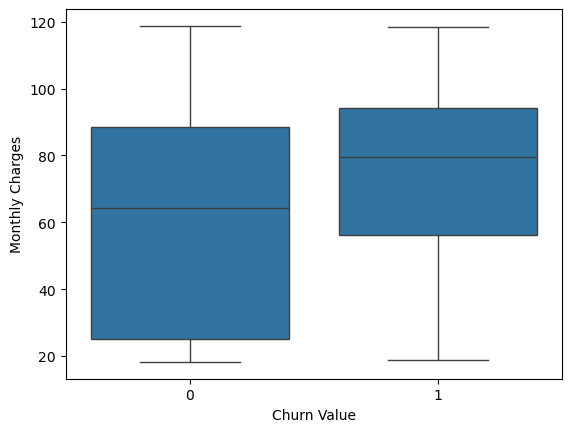

In [73]:
sns.boxplot(x='Churn Value', y='Monthly Charges', data=df)

### Observation 3: Monthly Charges vs Churn

The analysis of monthly charges reveals a clear relationship between pricing and customer churn.

- **Higher monthly charges correlate with higher churn rates.**
- The **median monthly charge for churned customers is approximately $80**, which is notably higher than the **~$65 median for retained customers**.

**Key Insight:**  
Customers paying higher monthly fees appear more likely to leave, suggesting that **pricing pressure or perceived value for money may play a significant role in churn behavior**.

<Axes: xlabel='Churn Value', ylabel='Tenure Months'>

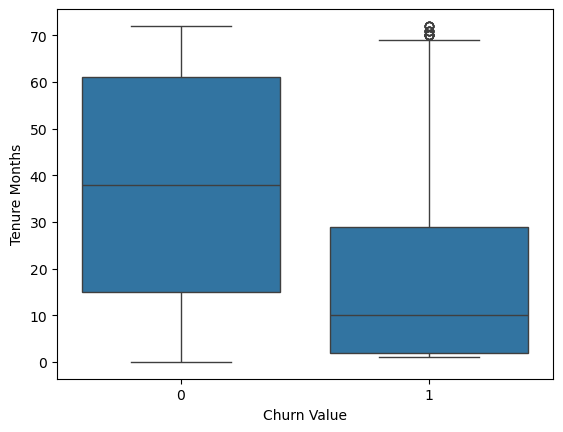

In [83]:
sns.boxplot(x='Churn Value', y='Tenure Months', data=df)

### Chart 1: Boxplot — Tenure vs Churn

**What the chart shows**

- Median tenure for **customers who stayed:** ~38 months  
- Median tenure for **customers who churned:** ~10 months  

**Key Observation**

Customers who churn tend to leave **much earlier** than customers who stay.

**Tenure Spread**

- **Retained customers**
  - Typical tenure ranges from **15 → 60+ months**
  - Indicates a strong base of **long-term loyal customers**

- **Churned customers**
  - Most tenure values fall between **0 → 25 months**
  - Suggests that churn mainly occurs **early in the customer lifecycle**

**Outliers**

A small number of churned customers appear around **~70 months**, showing that long-term customers can still churn, but this is **uncommon**.

**Key Takeaway**

The boxplot clearly indicates that **customers with shorter tenure are significantly more likely to churn**, while customers who stay longer tend to remain loyal.

<Axes: xlabel='Tenure Months', ylabel='Count'>

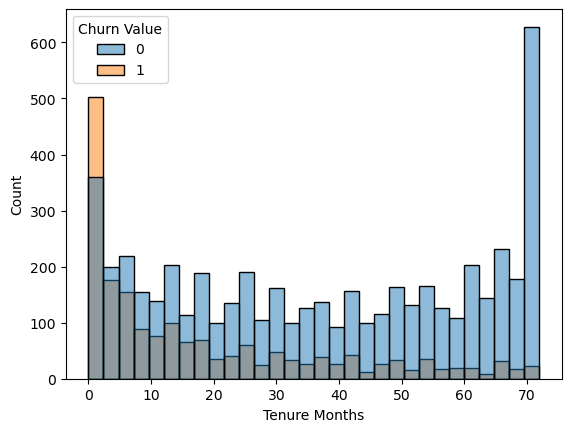

In [84]:
sns.histplot(data=df, x='Tenure Months', hue='Churn Value', bins=30)

### Chart 2: Tenure Distribution by Churn

**What the chart shows**

The tenure distribution highlights how churn behavior changes as customers stay longer with the service.

**Key Patterns**

- A large portion of churn occurs within **0–10 months**
- After **20–30 months**, the frequency of churn **drops significantly**

**Loyal Customer Segment**

A noticeable number of customers have **70+ months of tenure**, representing a group of **highly retained long-term users**.

**Key Insight**

Customers are **most likely to churn within the first 12 months** after joining.

Once customers remain beyond **about 24 months**, the probability of churn **decreases significantly**, indicating stronger loyalty.

**Business Implication**

Improving the **early customer experience and engagement** can help reduce churn and increase long-term retention.